# ESN Exploration: MSFT Single-Stock Forecasting

This notebook explores Echo State Networks on Microsoft (`MSFT`) daily market data. It has two parts:

- A reproducible DeepESN regression experiment on MSFT next-step log returns.
- A W&B Bayesian sweep configuration for 50 single-layer ESN runs with reasonable reservoir and readout hyperparameters.

The target is the next normalized MSFT log return generated by `make_single_stock_df`.

In [1]:
from pathlib import Path
import random
import sys
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset



from src.my_engine.config import MetricsConfig, ModelConfig, TrainerConfig
from src.my_engine.data import get_dataloaders
from src.my_engine.financial_data import make_single_stock_df
from src.my_engine.sweep import make_train_sweep
from src.my_engine.trainer import Trainer, RidgeRegressionTrainer
from src.my_engine.utils import build_model, make_optimizer
from pprint import pprint

In [2]:
PROJECT_ROOT = '/home/alexsearle/Documents/Bucknell/SP26/csci357_final_project'
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

if os.getcwd() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

In [3]:
SEED = 357
TICKER = "MSFT"
PERIOD = "5y"
WINDOW_SIZE = 30
TRAIN_SPLIT = 0.75
VAL_SPLIT = 0.15

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## MSFT Data

`make_single_stock_df` downloads MSFT data from Yahoo Finance, engineers price/volume/volatility features, standardizes the features using the training segment, and converts the result into rolling windows. The model sees a 30-day sequence and predicts the next scaled log return.

In [4]:
train_ds_raw, val_ds_raw, test_ds_raw, feature_scaler, features = make_single_stock_df(
    ticker=TICKER,
    period=PERIOD,
    train_split=TRAIN_SPLIT,
    val_split=VAL_SPLIT,
    window_size=WINDOW_SIZE,
)

def with_column_targets(dataset: TensorDataset) -> TensorDataset:
    X, y = dataset.tensors
    if y.ndim == 1:
        y = y.unsqueeze(1)
    return TensorDataset(X.float(), y.float())

train_ds = with_column_targets(train_ds_raw)
val_ds = with_column_targets(val_ds_raw)
test_ds = with_column_targets(test_ds_raw) if test_ds_raw is not None else None

# make_single_stock_df returns validation windows from the full post-train span.
# Trim it so validation and test are disjoint for model selection vs. final evaluation.
if test_ds is not None:
    intended_val_windows = len(val_ds) - len(test_ds) - WINDOW_SIZE - 1
    if intended_val_windows <= 0:
        raise ValueError("Validation split is too small for the selected window size.")
    val_X, val_y = val_ds.tensors
    val_ds = TensorDataset(val_X[:intended_val_windows], val_y[:intended_val_windows])

n_features = train_ds.tensors[0].shape[-1]
print(f"train windows: {len(train_ds):,}")
print(f"val windows:   {len(val_ds):,}")
print(f"test windows:  {len(test_ds):,}")
print(f"sequence shape: {tuple(train_ds.tensors[0].shape[1:])}")
print(f"features ({len(features)}): {features}")

[*********************100%***********************]  1 of 1 completed


train windows: 873
val windows:   149
test windows:  91
sequence shape: (30, 11)
features (11): ['log_returns', 'log_volume', 'log_intraday_chng', '10_log_returns_ma', '20_log_returns_ma', '50_log_returns_ma', 'open_close', 'overnight_gap', 'ret_1', 'ret_5', 'variance']


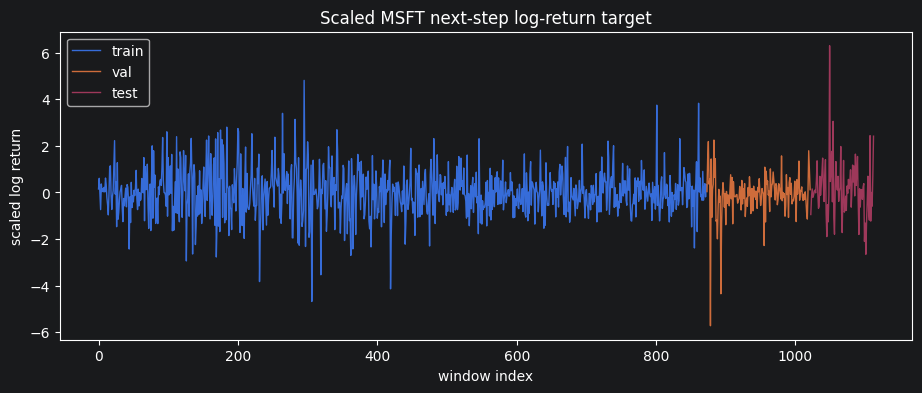

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train_ds.tensors[1].numpy(), label="train", linewidth=1.0)
ax.plot(
    range(len(train_ds), len(train_ds) + len(val_ds)),
    val_ds.tensors[1].numpy(),
    label="val",
    linewidth=1.0,
)
if test_ds is not None:
    offset = len(train_ds) + len(val_ds)
    ax.plot(
        range(offset, offset + len(test_ds)),
        test_ds.tensors[1].numpy(),
        label="test",
        linewidth=1.0,
    )
ax.set_title("Scaled MSFT next-step log-return target")
ax.set_xlabel("window index")
ax.set_ylabel("scaled log return")
ax.legend()
plt.show()

## Training Helpers

The project trainer supports regression metrics through `MetricsConfig`. The helper below evaluates predictions in scaled target space and in approximate original log-return units by inverting the scaler column corresponding to `log_returns`.

In [6]:
def inverse_scaled_target(values):
    target_idx = features.index("log_returns")
    values = np.asarray(values).reshape(-1)
    return values * feature_scaler.scale_[target_idx] + feature_scaler.mean_[target_idx]

@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    preds = []
    targets = []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        preds.append(model(X_batch).cpu())
        targets.append(y_batch.cpu())
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

def regression_report(pred_scaled, y_scaled):
    pred_scaled = np.asarray(pred_scaled).reshape(-1)
    y_scaled = np.asarray(y_scaled).reshape(-1)
    pred_raw = inverse_scaled_target(pred_scaled)
    y_raw = inverse_scaled_target(y_scaled)
    return {
        "scaled_mse": float(np.mean((pred_scaled - y_scaled) ** 2)),
        "scaled_mae": float(np.mean(np.abs(pred_scaled - y_scaled))),
        "raw_log_return_mse": float(np.mean((pred_raw - y_raw) ** 2)),
        "raw_log_return_mae": float(np.mean(np.abs(pred_raw - y_raw))),
        "directional_accuracy": float(np.mean(np.sign(pred_raw) == np.sign(y_raw))),
    }

def evaluate_model(model, loader, device):
    pred_scaled, y_scaled = predict(model, loader, device)
    return regression_report(pred_scaled, y_scaled), pred_scaled, y_scaled

## Baselines

Use simple baselines before judging the ESN. For stock returns, a zero-return forecast is often difficult to beat on MSE, so it is a useful sanity check.

In [7]:
zero_val = np.zeros_like(val_ds.tensors[1].numpy())
last_step_return_val = val_ds.tensors[0][:, -1, features.index("log_returns")].unsqueeze(1).numpy()

baseline_results = pd.DataFrame(
    [
        {"model": "zero_scaled_return", **regression_report(zero_val, val_ds.tensors[1].numpy())},
        {"model": "last_observed_return", **regression_report(last_step_return_val, val_ds.tensors[1].numpy())},
    ]
)
baseline_results

,model,scaled_mse,scaled_mae,raw_log_return_mse,raw_log_return_mae,directional_accuracy
0,zero_scaled_return,0.828991,0.562239,0.000234,0.009443,0.563758
1,last_observed_return,1.695199,0.856786,0.000478,0.014390,0.483221


## DeepESN Experiment

This model stacks fixed reservoirs and trains only the readout. The reservoir size and depth are deliberately moderate so the cell remains notebook-friendly while still testing whether deeper reservoir dynamics help on MSFT.

In [8]:
deep_esn_config = ModelConfig(
    model_type="deep_esn",
    reservoir_size=300,
    rnn_num_layers=3,
    spectral_radius=0.95,
    reservoir_sparsity=0.85,
    input_scale=0.25,
    leak_rate=0.35,
    hidden_units=[128, 64],
    dropout=[0.10, 0.10],
)

trainer_config = TrainerConfig(
    trainer_batch_size=128,
    evaluator_batch_size=512,
    learning_rate=1e-3,
    num_epochs=40,
    optimizer_name="Adam",
    weight_decay=1e-4,
    early_stopping_patience=8,
    early_stopping_min_delta=1e-5,
    use_scheduler=True,
    scheduler_type="reduce_on_plateau",
    scheduler_patience=3,
    scheduler_gamma=0.5,
    scheduler_min_lr=1e-5,
    device=device,
    num_workers=0,
    pin_memory=False,
)

train_loader, val_loader, test_loader = get_dataloaders(
    train_ds,
    val_ds,
    test_ds,
    train_batch_size=trainer_config.trainer_batch_size,
    eval_batch_size=trainer_config.evaluator_batch_size,
    time_series=True,
)

metrics_config = MetricsConfig(task="regression", names=["mae", "mse", "r2"])

deep_esn_model = build_model(
    input_spec=n_features,
    num_outputs=1,
    config=deep_esn_config,
)
optimizer = make_optimizer(deep_esn_model.parameters(), trainer_config)
criterion = nn.MSELoss()

print(deep_esn_model)
print("parameters:", deep_esn_model.num_parameters())

DeepESN(input=11, layers=3, reservoir=300, out=1)
parameters: (453601, 0)


In [9]:
trainer = RidgeRegressionTrainer(
    model=deep_esn_model,
    criterion=criterion,
    config=trainer_config,
)

history = trainer.fit(train_loader, val_loader)
history

{'train_loss': 0.5302902406843257,
 'train_acc': 0.0,
 'val_loss': 3.5417120456695557,
 'val_acc': 0.0}

In [10]:
val_report, val_pred_scaled, val_y_scaled = evaluate_model(deep_esn_model, val_loader, device)
test_report = None
if test_loader is not None:
    test_report, test_pred_scaled, test_y_scaled = evaluate_model(deep_esn_model, test_loader, device)

pd.DataFrame(
    [
        {"split": "validation", **val_report},
        *([] if test_report is None else [{"split": "test", **test_report}]),
    ]
)

,split,scaled_mse,scaled_mae,raw_log_return_mse,raw_log_return_mae,directional_accuracy
0,validation,3.541712,1.506345,0.000999,0.025300,0.476510
1,test,5.770130,1.877029,0.001628,0.031526,0.582418


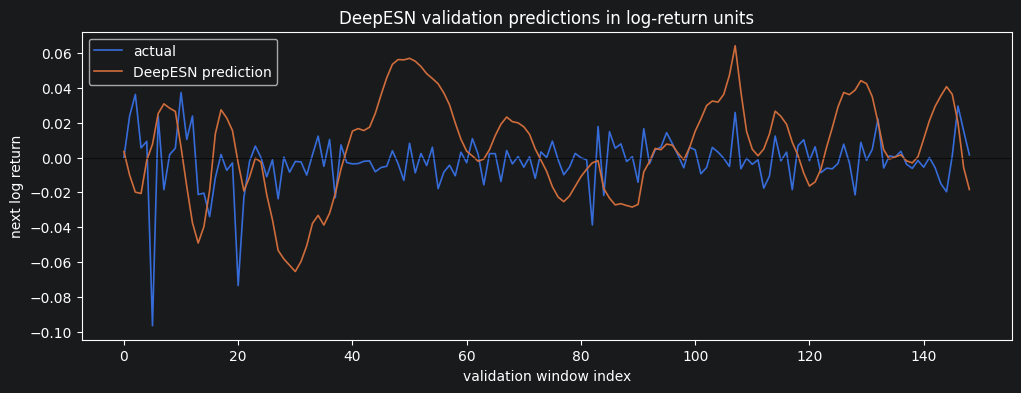

In [11]:
val_pred_raw = inverse_scaled_target(val_pred_scaled)
val_y_raw = inverse_scaled_target(val_y_scaled)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(val_y_raw, label="actual", linewidth=1.2)
ax.plot(val_pred_raw, label="DeepESN prediction", linewidth=1.2)
ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("DeepESN validation predictions in log-return units")
ax.set_xlabel("validation window index")
ax.set_ylabel("next log return")
ax.legend()
plt.show()

KeyError: 'train_losses'

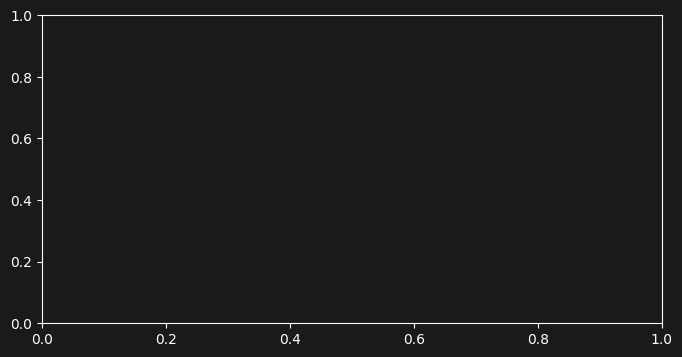

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["train_losses"], label="train")
ax.plot(history["val_losses"], label="validation")
ax.set_title("DeepESN MSE loss")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.legend()
plt.show()

## Bayesian Sweep: 50 ESNs

The sweep below searches single-layer ESNs. It minimizes validation loss over reservoir dynamics, readout size, learning rate, and regularization. Set `RUN_SWEEP = True` after logging into W&B.

In [27]:
import wandb

WANDB_PROJECT = "csci357-msft-esn"
WANDB_ENTITY = None

esn_sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_loss", "goal": "minimize"},
    "early_terminate": {"type": "hyperband", "min_iter": 8},
    "parameters": {
        "model_type": {"value": "esn"},
        "num_epochs": {"value": 35},
        "loss_name": {"value": "mse"},
        "reservoir_size": {"values": [100, 200, 300, 500]},
        "spectral_radius": {"distribution": "uniform", "min": 0.4, "max": 1.3},
        "reservoir_sparsity": {"distribution": "uniform", "min": 0.50, "max": 0.95},
        "input_scale": {"distribution": "uniform", "min": 0.05, "max": 0.80},
        "leak_rate": {"distribution": "uniform", "min": 0.05, "max": 1.00},
        "ridge_alpha": {"distribution": "log_uniform_values", "min": 1e-3, "max": 10},
        "hidden_units": {"values": [[32], [64], [128], [128, 64], [256, 128]]},
        "num_workers": {"value": 0},
        "pin_memory": {"value": False},
    },
}

esn_sweep_config

{'method': 'bayes',
 'metric': {'name': 'val_loss', 'goal': 'minimize'},
 'early_terminate': {'type': 'hyperband', 'min_iter': 8},
 'parameters': {'model_type': {'value': 'esn'},
  'num_epochs': {'value': 35},
  'loss_name': {'value': 'mse'},
  'reservoir_size': {'values': [100, 200, 300, 500]},
  'spectral_radius': {'distribution': 'uniform', 'min': 0.4, 'max': 1.3},
  'reservoir_sparsity': {'distribution': 'uniform', 'min': 0.5, 'max': 0.95},
  'input_scale': {'distribution': 'uniform', 'min': 0.05, 'max': 0.8},
  'leak_rate': {'distribution': 'uniform', 'min': 0.05, 'max': 1.0},
  'ridge_alpha': {'distribution': 'log_uniform_values',
   'min': 0.001,
   'max': 10},
  'hidden_units': {'values': [[32], [64], [128], [128, 64], [256, 128]]},
  'num_workers': {'value': 0},
  'pin_memory': {'value': False}}}

In [28]:
RUN_SWEEP = True

if RUN_SWEEP:
    sweep_id = wandb.sweep(
        sweep=esn_sweep_config,
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
    )

    train_sweep = make_train_sweep(
        wandb_project_name=WANDB_PROJECT,
        wandb_entity_name=WANDB_ENTITY,
        datasets=(train_ds, val_ds),
        device=device,
        input_spec=n_features,
        num_outputs=1,
        wandb_name_prefix=f"{TICKER.lower()}_single_esn",
        trainer_type="ridge"
    )

    wandb.agent(sweep_id, function=train_sweep, count=50)
else:
    print("Sweep is configured but not launched. Set RUN_SWEEP = True to start 50 Bayesian ESN runs.")

Create sweep with ID: e85e4ft6
Sweep URL: https://wandb.ai/sas073-bucknell-university/csci357-msft-esn/sweeps/e85e4ft6


wandb: Agent Starting Run: ngxla0px with config:
wandb: 	hidden_units: [32]
wandb: 	input_scale: 0.16920676699233916
wandb: 	leak_rate: 0.9366977481661284
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 300
wandb: 	reservoir_sparsity: 0.608795679126341
wandb: 	ridge_alpha: 0.8375011804857703
wandb: 	spectral_radius: 1.0287645724888197
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [32], 'input_scale': 0.16920676699233916, 'leak_rate': 0.9366977481661284, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 300, 'reservoir_sparsity': 0.608795679126341, 'ridge_alpha': 0.8375011804857703, 'spectral_radius': 1.0287645724888197}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs300_sr1.03_sp0.61_wd0.00000
esn
✓ Run complete! Final val_loss: 1.2723, val_acc: 0.00%


wandb: Agent Starting Run: 3h5dm8vl with config:
wandb: 	hidden_units: [32]
wandb: 	input_scale: 0.2418605325169349
wandb: 	leak_rate: 0.07020682438312917
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 500
wandb: 	reservoir_sparsity: 0.9358845686211268
wandb: 	ridge_alpha: 0.006980186862350648
wandb: 	spectral_radius: 1.1370283630473232
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [32], 'input_scale': 0.2418605325169349, 'leak_rate': 0.07020682438312917, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 500, 'reservoir_sparsity': 0.9358845686211268, 'ridge_alpha': 0.006980186862350648, 'spectral_radius': 1.1370283630473232}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs500_sr1.14_sp0.94_wd0.00000
esn
✓ Run complete! Final val_loss: 16.2443, val_acc: 0.00%


...

wandb.config: {'hidden_units': [256, 128], 'input_scale': 0.6221188662007447, 'leak_rate': 0.6511629084616938, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.5468940031887162, 'ridge_alpha': 1.6816207179026903, 'spectral_radius': 0.7149711707026842}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.71_sp0.55_wd0.00000
esn
✓ Run complete! Final val_loss: 1.0704, val_acc: 0.00%


wandb: Agent Starting Run: 0k5a9myj with config:
wandb: 	hidden_units: [32]
wandb: 	input_scale: 0.6785304126563827
wandb: 	leak_rate: 0.7487068146473401
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 100
wandb: 	reservoir_sparsity: 0.5253933571827051
wandb: 	ridge_alpha: 6.356276551618962
wandb: 	spectral_radius: 0.9864273861941254
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [32], 'input_scale': 0.6785304126563827, 'leak_rate': 0.7487068146473401, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.5253933571827051, 'ridge_alpha': 6.356276551618962, 'spectral_radius': 0.9864273861941254}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.99_sp0.53_wd0.00000
esn
✓ Run complete! Final val_loss: 0.9065, val_acc: 0.00%


wandb: Agent Starting Run: quc7qjmf with config:
wandb: 	hidden_units: [32]
wandb: 	input_scale: 0.3564489848903304
wandb: 	leak_rate: 0.9346899263864078
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 100
wandb: 	reservoir_sparsity: 0.5156612498747913
wandb: 	ridge_alpha: 5.248814433681662
wandb: 	spectral_radius: 0.6594164254805932
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [32], 'input_scale': 0.3564489848903304, 'leak_rate': 0.9346899263864078, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.5156612498747913, 'ridge_alpha': 5.248814433681662, 'spectral_radius': 0.6594164254805932}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.66_sp0.52_wd0.00000
esn
✓ Run complete! Final val_loss: 0.8728, val_acc: 0.00%


In [29]:
from my_engine.sweep import terminate_sweep

terminate_sweep(sweep_id)

Sweep e85e4ft6 current state is: RUNNING
Stopping sweep sas073-bucknell-university/csci357-msft-esn/e85e4ft6


Error processing line 1 of /home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
wandb: Stopping sweep sas073-bucknell-university/csci357-msft-esn/e85e4ft6


Sweep sas073-bucknell-university/csci357-msft-esn/e85e4ft6 stopped successfully


wandb: Done.


True

In [30]:
from src.my_engine.sweep import get_best_sweep_run_and_config

best_run, best_config, best_metric = get_best_sweep_run_and_config(
    entity="",
    project=WANDB_PROJECT,
    sweep_id=sweep_id,
    metric_name="val_loss",
    maximize=False,
)

print(best_run.name)
print(best_metric)
pprint(best_config)

msft_single_esn_esn_bs64_lr0.00100_rs500_sr0.82_sp0.52_wd0.00000
0.7819167971611023
{'hidden_units': [32],
 'input_scale': 0.1574156235243087,
 'leak_rate': 0.9592043653783092,
 'loss_name': 'mse',
 'model_type': 'esn',
 'num_epochs': 35,
 'num_workers': 0,
 'pin_memory': False,
 'reservoir_size': 500,
 'reservoir_sparsity': 0.5218056133163816,
 'ridge_alpha': 8.429721773870401,
 'spectral_radius': 0.8185685272609273}


In [37]:
best_esn_config = ModelConfig(
    model_type=best_config['model_type'],
    leak_rate=best_config['leak_rate'],
    spectral_radius=best_config['spectral_radius'],
    reservoir_size=best_config['reservoir_size'],
    reservoir_sparsity=best_config['reservoir_sparsity'],
    hidden_units=best_config['hidden_units'],
    input_scale=best_config['input_scale'],
)

best_esn_model = build_model(input_spec=len(features), config=best_esn_config, num_outputs=1)

best_esn_trainer_config = TrainerConfig(
    num_epochs=50,
    device=device,
)

train_loader, val_loader, test_loader = get_dataloaders(
    train_ds=train_ds,
    eval_ds=val_ds,
    test_ds=test_ds,
    train_batch_size=best_esn_trainer_config.trainer_batch_size,
    eval_batch_size=best_esn_trainer_config.evaluator_batch_size,
    time_series=True,
)

trainer = RidgeRegressionTrainer(
    model=best_esn_model,
    criterion=torch.nn.MSELoss(),
    config=best_esn_trainer_config,
    ridge_alpha=best_config['ridge_alpha'],
)
best_results = trainer.fit(train_loader, test_loader)

In [ ]:
best_weights = torch.load("checkpoints/best.pt", weights_only=True)
best_esn_model.load_state_dict(best_weights['model_state_dict'])

In [41]:
from sklearn.metrics import precision_score
from src.my_engine.utils import get_direction_accuracy

deep_best_dir_acc, true_dirs, pred_dirs = get_direction_accuracy(best_esn_model, test_loader, feature_scaler, features.index('log_returns'))
precision = precision_score(true_dirs, pred_dirs)
print(f"Directional accuracy: {deep_best_dir_acc:.2%}")
print(f"Directional precision: {precision:.2%}")

Directional accuracy: 57.14%
Directional precision: 60.00%


## Interpretation Notes

- Compare DeepESN validation/test MSE against the zero-return baseline before relying on directional accuracy.
- If the sweep finds strong ESN configurations, retrain the best configuration once with a fixed seed and evaluate on the held-out test windows.
- For financial return forecasting, small differences in scaled MSE can be noise. Use repeated seeds or walk-forward splits before making a stronger claim.